# 🎯 Objectif 1 — Extraction Automatique des Compétences
> **Module NLP** : Analyse des descriptions de formations / offres d'emploi  
> Dataset : `activities.xlsx` (20 298 entrées réelles)

---
**Pipeline complet :**
1. Chargement & exploration du dataset
2. Nettoyage du texte
3. Extraction des compétences (spaCy EntityRuler)
4. Classification supervisée (KNN + TF-IDF)
5. Évaluation & Benchmarking
6. Export de la sortie normalisée

## 📦 0. Installation des dépendances

In [ ]:
!pip install -q spacy openpyxl
!python -m spacy download en_core_web_sm -q
print('✅ Dépendances installées')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Dépendances installées


## 📂 1. Chargement du Dataset

In [ ]:
import subprocess
result = subprocess.run(
    ['find', '/content/drive', '-name', 'activities.xlsx', '-type', 'f'],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else "Fichier non trouvé dans Drive")

Fichier non trouvé dans Drive


In [ ]:
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import io

# Authentification
auth.authenticate_user()
service = build('drive', 'v3')

# Chercher le fichier activities.xlsx
results = service.files().list(
    q="name='activities.xlsx'",
    spaces='drive',
    fields='files(id, name, owners)'
).execute()

files = results.get('files', [])
if not files:
    print("❌ Fichier non trouvé")
else:
    for f in files:
        print(f"✅ Trouvé : {f['name']} | ID: {f['id']}")

    # Télécharger le premier résultat
    file_id = files[0]['id']
    request = service.files().get_media(fileId=file_id)
    fh = io.FileIO('activities.xlsx', 'wb')
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        status, done = downloader.next_chunk()
    print("✅ Téléchargé dans /content/activities.xlsx")

# Mettre à jour FILE_PATH
FILE_PATH = '/content/activities.xlsx'

✅ Trouvé : activities.xlsx | ID: 1UzRw2k0qD6UeGypyjP_qH4W_M9rf9gSJ
✅ Téléchargé dans /content/activities.xlsx


In [ ]:
import pandas as pd

# Chargement du fichier téléchargé
FILE_PATH = '/content/activities.xlsx'
df = pd.read_excel(FILE_PATH)

print(f"✅ DataFrame chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(df.columns.tolist())

✅ DataFrame chargé : 20298 lignes × 16 colonnes
['company_name', 'job_title', 'employment_type', 'seniority', 'job_category', 'location', 'salary', 'min_experience', 'skills_required', 'requirements_and_role', 'job_requirements', 'company_info', 'posting_date', 'expiry_date', 'no_of_applications', 'job_id']


In [ ]:
# ─── Exploration initiale ───
print('=== Informations générales ===')
df.info()

print('\n=== Valeurs manquantes ===')
missing = df.isnull().sum()
print(missing[missing > 0])

print('\n=== Distribution job_category ===')
if 'job_category' in df.columns:
    print(df['job_category'].value_counts().head(15))

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20298 entries, 0 to 20297
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company_name           20298 non-null  object 
 1   job_title              20298 non-null  object 
 2   employment_type        20298 non-null  object 
 3   seniority              20006 non-null  object 
 4   job_category           20298 non-null  object 
 5   location               20298 non-null  object 
 6   salary                 20298 non-null  object 
 7   min_experience         20298 non-null  object 
 8   skills_required        20298 non-null  object 
 9   requirements_and_role  20292 non-null  object 
 10  job_requirements       20286 non-null  object 
 11  company_info           588 non-null    object 
 12  posting_date           0 non-null      float64
 13  expiry_date            0 non-null      float64
 14  no_of_applications     

## 🧹 2. Nettoyage & Préparation du texte

In [ ]:
import re

# ─── Colonnes textuelles disponibles ───
# On combine requirements_and_role + job_requirements pour maximiser l'info
TEXT_COLS = ['requirements_and_role', 'job_requirements', 'job_title']

# Gestion des valeurs manquantes
for col in TEXT_COLS:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Création de la colonne texte principale
df['raw_text'] = df[['requirements_and_role', 'job_requirements']].apply(
    lambda x: ' '.join(x.astype(str)), axis=1
)

# ─── Fonction de nettoyage ───
def clean_text(text):
    """Nettoie le texte brut pour l'analyse NLP."""
    if not isinstance(text, str):
        return ''
    text = text.lower()                          # minuscules
    text = re.sub(r'http\S+|www\S+', '', text)  # supprime les URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)    # garde lettres + espaces
    text = re.sub(r'\s+', ' ', text).strip()    # normalise les espaces
    return text

df['clean_text'] = df['raw_text'].apply(clean_text)

# Filtre : garde les lignes avec suffisamment de texte
df = df[df['clean_text'].str.split().str.len() >= 5].reset_index(drop=True)

print(f'✅ Dataset après nettoyage : {df.shape[0]} lignes')
print('\nExemple texte nettoyé :')
print(df['clean_text'].iloc[0][:300])

✅ Dataset après nettoyage : 20287 lignes

Exemple texte nettoyé :
providing support director admin manager assisting daily day day activities carry indoor sales network tele marketing exp willing learn also generate quotation invoicing etc sales coordination functions requirements preferably least year relevant exp


## 🏷️ 3. Extraction des Compétences (spaCy EntityRuler)

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm')

# ─── Dictionnaire de compétences étendu ───
SKILL_PATTERNS = [
    # ── TECHNICAL SKILLS ──
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'python'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'sql'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'java'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'javascript'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'r'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'c++'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'c#'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'react'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'angular'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'vue'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'node'}, {'LOWER': 'js'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'aws'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'azure'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'docker'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'kubernetes'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'git'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'linux'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'machine'}, {'LOWER': 'learning'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'deep'}, {'LOWER': 'learning'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'data'}, {'LOWER': 'analysis'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'data'}, {'LOWER': 'science'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'data'}, {'LOWER': 'engineering'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'artificial'}, {'LOWER': 'intelligence'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'natural'}, {'LOWER': 'language'}, {'LOWER': 'processing'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'nlp'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'tableau'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'power'}, {'LOWER': 'bi'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'tensorflow'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'pytorch'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'scikit'}, {'LOWER': 'learn'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'excel'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'photoshop'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'autocad'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'networking'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'cybersecurity'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'cloud'}, {'LOWER': 'computing'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'devops'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'api'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'restful'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'microservices'}]},
    {'label': 'TECHNICAL_SKILL', 'pattern': [{'LOWER': 'sap'}]},

    # ── MANAGERIAL SKILLS ──
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'leadership'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'planning'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'strategic'}, {'LOWER': 'planning'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'project'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'team'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'team'}, {'LOWER': 'leadership'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'agile'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'scrum'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'kanban'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'budgeting'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'budget'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'vendor'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'stakeholder'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'change'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'risk'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'performance'}, {'LOWER': 'management'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'decision'}, {'LOWER': 'making'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'coaching'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'mentoring'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'negotiation'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'coordination'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'recruitment'}]},
    {'label': 'MANAGERIAL_SKILL', 'pattern': [{'LOWER': 'training'}]},

    # ── SOFT SKILLS ──
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'communication'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'teamwork'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'problem'}, {'LOWER': 'solving'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'critical'}, {'LOWER': 'thinking'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'adaptability'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'time'}, {'LOWER': 'management'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'creativity'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'collaboration'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'interpersonal'}, {'LOWER': 'skills'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'presentation'}, {'LOWER': 'skills'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'analytical'}, {'LOWER': 'skills'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'attention'}, {'LOWER': 'to'}, {'LOWER': 'detail'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'multitasking'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'flexibility'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'initiative'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'customer'}, {'LOWER': 'service'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'relationship'}, {'LOWER': 'management'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'emotional'}, {'LOWER': 'intelligence'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'work'}, {'LOWER': 'ethic'}]},
    {'label': 'SOFT_SKILL', 'pattern': [{'LOWER': 'public'}, {'LOWER': 'speaking'}]},
]

# Ajout du ruler dans le pipeline
ruler = nlp.add_pipe('entity_ruler', before='ner')
ruler.add_patterns(SKILL_PATTERNS)

print(f'✅ EntityRuler configuré avec {len(SKILL_PATTERNS)} patterns')
print(f'   • TECHNICAL_SKILL : {sum(1 for p in SKILL_PATTERNS if p["label"]=="TECHNICAL_SKILL")} patterns')
print(f'   • MANAGERIAL_SKILL : {sum(1 for p in SKILL_PATTERNS if p["label"]=="MANAGERIAL_SKILL")} patterns')
print(f'   • SOFT_SKILL : {sum(1 for p in SKILL_PATTERNS if p["label"]=="SOFT_SKILL")} patterns')

✅ EntityRuler configuré avec 85 patterns
   • TECHNICAL_SKILL : 41 patterns
   • MANAGERIAL_SKILL : 24 patterns
   • SOFT_SKILL : 20 patterns


In [ ]:
from tqdm import tqdm
tqdm.pandas()

def extract_skills_nlp(text):
    """Extrait les compétences par catégorie via spaCy EntityRuler."""
    if not isinstance(text, str) or len(text.strip()) < 5:
        return {'TECHNICAL_SKILL': [], 'MANAGERIAL_SKILL': [], 'SOFT_SKILL': []}

    doc = nlp(text[:5000])  # limite pour performance
    extracted = {'TECHNICAL_SKILL': set(), 'MANAGERIAL_SKILL': set(), 'SOFT_SKILL': set()}

    for ent in doc.ents:
        if ent.label_ in extracted:
            extracted[ent.label_].add(ent.text.lower().strip())

    return {k: sorted(v) for k, v in extracted.items()}


print('🔄 Extraction des compétences en cours (peut prendre 1-2 min)...')
skills_extracted = df['clean_text'].progress_apply(extract_skills_nlp)

# Décomposition en colonnes séparées
df['Technical_Skills']   = skills_extracted.apply(lambda x: x['TECHNICAL_SKILL'])
df['Managerial_Skills']  = skills_extracted.apply(lambda x: x['MANAGERIAL_SKILL'])
df['Soft_Skills_NLP']    = skills_extracted.apply(lambda x: x['SOFT_SKILL'])
df['All_Skills']         = df['Technical_Skills'] + df['Managerial_Skills'] + df['Soft_Skills_NLP']

df['Technical_Count']  = df['Technical_Skills'].apply(len)
df['Managerial_Count'] = df['Managerial_Skills'].apply(len)
df['Soft_Count']       = df['Soft_Skills_NLP'].apply(len)
df['Total_Skills']     = df['All_Skills'].apply(len)

print('\n✅ Extraction terminée !')
print(f"   Lignes avec au moins 1 compétence : {(df['Total_Skills'] > 0).sum()} / {len(df)}")
df[['job_title', 'Technical_Skills', 'Managerial_Skills', 'Soft_Skills_NLP']].head(5)

🔄 Extraction des compétences en cours (peut prendre 1-2 min)...


  1%|          | 227/20287 [00:08<09:21, 35.72it/s]

## 📊 4. Analyse & Visualisation des compétences extraites

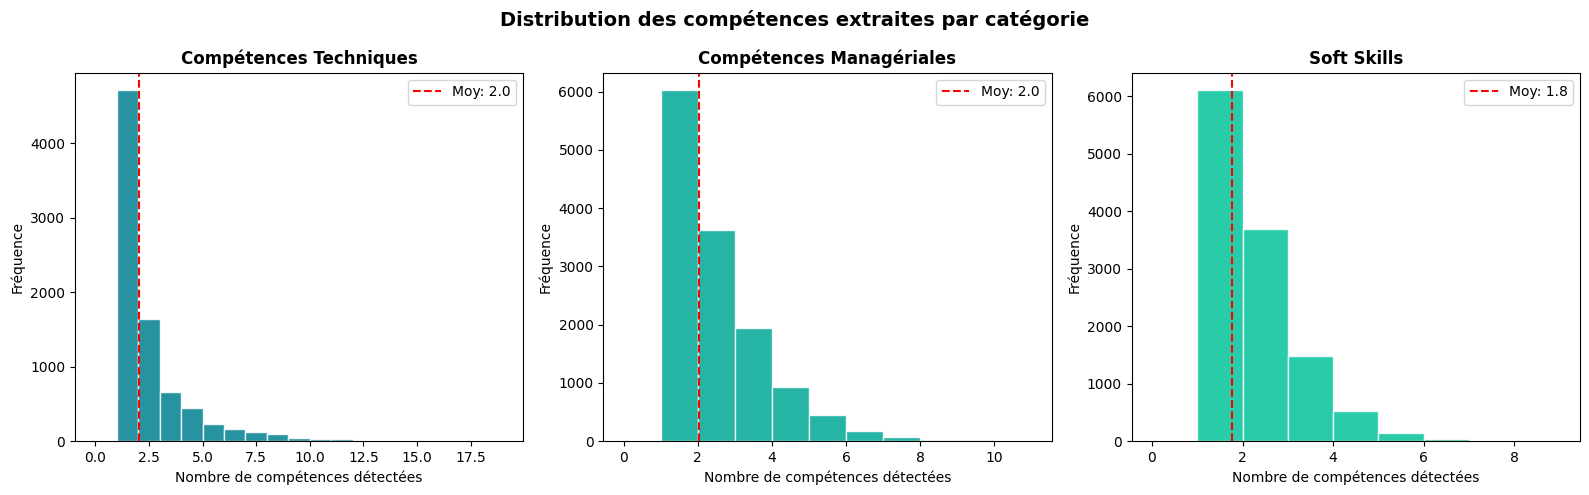

📸 Graphique sauvegardé : distribution_competences.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# ─── Distribution par catégorie ───
categories = ['Technical_Count', 'Managerial_Count', 'Soft_Count']
labels     = ['Compétences Techniques', 'Compétences Managériales', 'Soft Skills']
colors     = ['#028090', '#00A896', '#02C39A']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution des compétences extraites par catégorie', fontsize=14, fontweight='bold')

for ax, col, label, color in zip(axes, categories, labels, colors):
    data = df[col][df[col] > 0]
    ax.hist(data, bins=range(0, data.max()+2), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Nombre de compétences détectées')
    ax.set_ylabel('Fréquence')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moy: {data.mean():.1f}')
    ax.legend()

plt.tight_layout()
plt.savefig('distribution_competences.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Graphique sauvegardé : distribution_competences.png')

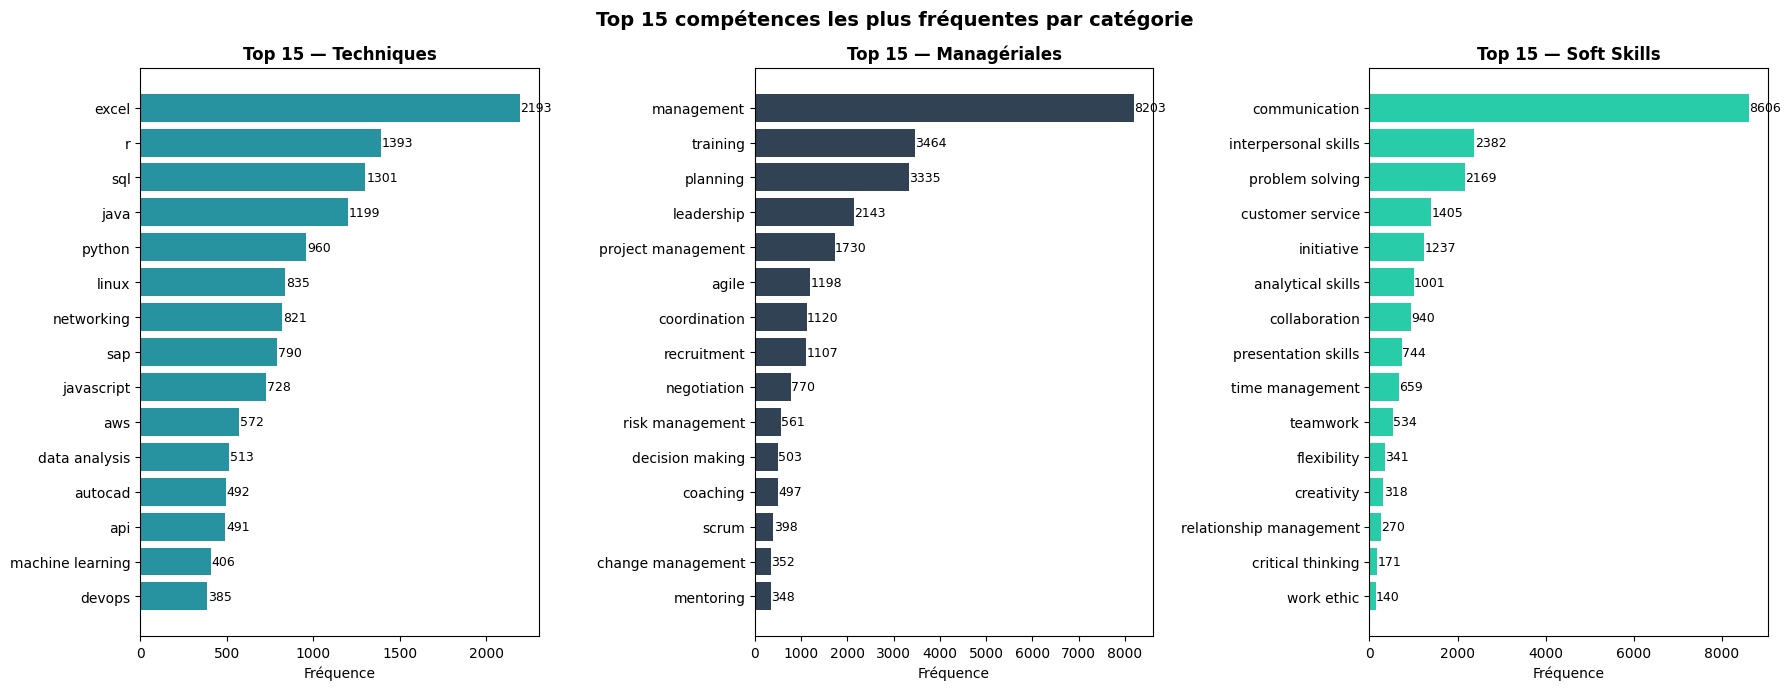

📸 Graphique sauvegardé : top_competences.png


In [ ]:
# ─── Top 20 compétences les plus fréquentes ───
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top 15 compétences les plus fréquentes par catégorie', fontsize=14, fontweight='bold')

skill_cols = [('Technical_Skills', 'Techniques', '#028090'),
              ('Managerial_Skills', 'Managériales', '#0D2137'),
              ('Soft_Skills_NLP',   'Soft Skills',  '#02C39A')]

for ax, (col, title, color) in zip(axes, skill_cols):
    counter = Counter([s for skills in df[col] for s in skills])
    top15 = counter.most_common(15)
    if not top15:
        ax.text(0.5, 0.5, 'Aucune compétence\ndétectée', ha='center', va='center')
        continue
    names, counts = zip(*top15)
    bars = ax.barh(list(names)[::-1], list(counts)[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top 15 — {title}', fontweight='bold')
    ax.set_xlabel('Fréquence')
    for bar, count in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_competences.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Graphique sauvegardé : top_competences.png')

📊 Répartition globale des compétences extraites :
   • Techniques    : 16,727 (25.7%)
   • Managériales  : 27,101 (41.7%)
   • Soft Skills   : 21,144 (32.5%)
   • TOTAL         : 64,972


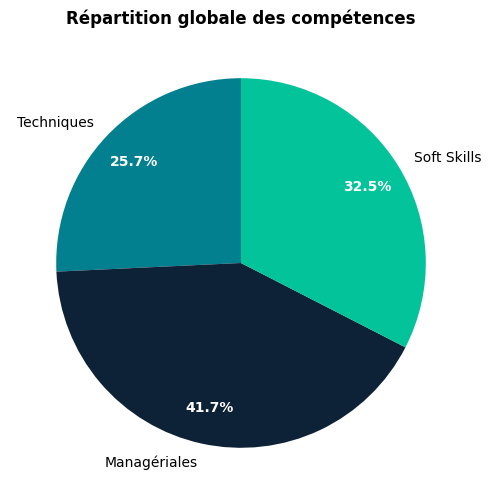

In [ ]:
# ─── Répartition globale (camembert) ───
total_tech = df['Technical_Count'].sum()
total_mgt  = df['Managerial_Count'].sum()
total_soft = df['Soft_Count'].sum()
total_all  = total_tech + total_mgt + total_soft

print(f'📊 Répartition globale des compétences extraites :')
print(f'   • Techniques    : {total_tech:,} ({100*total_tech/total_all:.1f}%)')
print(f'   • Managériales  : {total_mgt:,} ({100*total_mgt/total_all:.1f}%)')
print(f'   • Soft Skills   : {total_soft:,} ({100*total_soft/total_all:.1f}%)')
print(f'   • TOTAL         : {total_all:,}')

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    [total_tech, total_mgt, total_soft],
    labels=['Techniques', 'Managériales', 'Soft Skills'],
    autopct='%1.1f%%',
    colors=['#028090', '#0D2137', '#02C39A'],
    startangle=90, pctdistance=0.8
)
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')
ax.set_title('Répartition globale des compétences', fontweight='bold')
plt.savefig('repartition_competences.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 5. Classification supervisée (KNN + TF-IDF)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import ast

# ─── Construction du dataset de classification ───
# Chaque compétence extraite devient un exemple avec son label

clf_rows = []
for _, row in df.iterrows():
    for skill in row['Technical_Skills']:
        clf_rows.append({'skill': skill, 'label': 'TECHNICAL_SKILL', 'source_text': row['clean_text'][:500]})
    for skill in row['Managerial_Skills']:
        clf_rows.append({'skill': skill, 'label': 'MANAGERIAL_SKILL', 'source_text': row['clean_text'][:500]})
    for skill in row['Soft_Skills_NLP']:
        clf_rows.append({'skill': skill, 'label': 'SOFT_SKILL', 'source_text': row['clean_text'][:500]})

clf_df = pd.DataFrame(clf_rows).drop_duplicates(subset=['skill', 'label']).reset_index(drop=True)

print(f'✅ Dataset de classification : {len(clf_df)} exemples')
print('\nDistribution des labels :')
print(clf_df['label'].value_counts())

✅ Dataset de classification : 82 exemples

Distribution des labels :
label
TECHNICAL_SKILL     39
MANAGERIAL_SKILL    24
SOFT_SKILL          19
Name: count, dtype: int64


In [ ]:
# ─── Vectorisation TF-IDF ───
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000,
    ngram_range=(1, 2)  # unigrammes + bigrammes
)

# On vectorise le contexte (source_text) pour apprendre le contexte d'apparition
X = vectorizer.fit_transform(clf_df['source_text'])
y = clf_df['label']

print(f'Shape TF-IDF : {X.shape}')
print(f'Vocabulaire : {len(vectorizer.vocabulary_)} termes')

# Top mots TF-IDF
import numpy as np
feature_names = vectorizer.get_feature_names_out()
tfidf_sum = np.array(X.sum(axis=0)).flatten()
top_idx = tfidf_sum.argsort()[-20:][::-1]
print('\nTop 20 termes TF-IDF :')
print([feature_names[i] for i in top_idx])

Shape TF-IDF : (82, 1000)
Vocabulaire : 1000 termes

Top 20 termes TF-IDF :
['business', 'team', 'data', 'management', 'support', 'customer', 'role', 'financial', 'sales', 'design', 'company', 'systems', 'including', 'ensure', 'manager', 'provide', 'requirements', 'looking', 'singapore', 'develop']


In [ ]:
# ─── Split Train / Test ───
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} exemples')
print(f'Test  : {X_test.shape[0]} exemples')

# ─── Entraînement des modèles ───
models = {
    'KNN (k=3)':              KNeighborsClassifier(n_neighbors=3, metric='cosine'),
    'KNN (k=5)':              KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    'Logistic Regression':    LogisticRegression(max_iter=500, random_state=42),
    'Naive Bayes':            MultinomialNB(alpha=0.1),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
print('\n🏋️ Entraînement des modèles...')
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = (y_pred == y_test).mean()
    results[name] = {'model': model, 'f1_macro': f1, 'accuracy': acc, 'y_pred': y_pred}
    print(f'   ✅ {name:<25} | F1 macro = {f1:.4f} | Accuracy = {acc:.4f}')

Train : 65 exemples
Test  : 17 exemples

🏋️ Entraînement des modèles...
   ✅ KNN (k=3)                 | F1 macro = 0.3668 | Accuracy = 0.5294
   ✅ KNN (k=5)                 | F1 macro = 0.3667 | Accuracy = 0.5294
   ✅ Logistic Regression       | F1 macro = 0.2222 | Accuracy = 0.4706
   ✅ Naive Bayes               | F1 macro = 0.2741 | Accuracy = 0.4118
   ✅ Random Forest             | F1 macro = 0.3362 | Accuracy = 0.4706


## 📈 6. Évaluation & Benchmarking

In [ ]:
# ─── Tableau de benchmarking ───
bench_df = pd.DataFrame([
    {'Modèle': name, 'F1 Macro': v['f1_macro'], 'Accuracy': v['accuracy']}
    for name, v in results.items()
]).sort_values('F1 Macro', ascending=False).reset_index(drop=True)

bench_df['F1 Macro']  = bench_df['F1 Macro'].round(4)
bench_df['Accuracy']  = bench_df['Accuracy'].round(4)
bench_df['Rang'] = range(1, len(bench_df)+1)
bench_df = bench_df[['Rang', 'Modèle', 'F1 Macro', 'Accuracy']]

print('=== 🏆 Benchmarking des modèles ===')
print(bench_df.to_string(index=False))

best_name = bench_df.iloc[0]['Modèle']
print(f'\n✅ Modèle retenu : {best_name}')

=== 🏆 Benchmarking des modèles ===
 Rang              Modèle  F1 Macro  Accuracy
    1           KNN (k=3)    0.3668    0.5294
    2           KNN (k=5)    0.3667    0.5294
    3       Random Forest    0.3362    0.4706
    4         Naive Bayes    0.2741    0.4118
    5 Logistic Regression    0.2222    0.4706

✅ Modèle retenu : KNN (k=3)


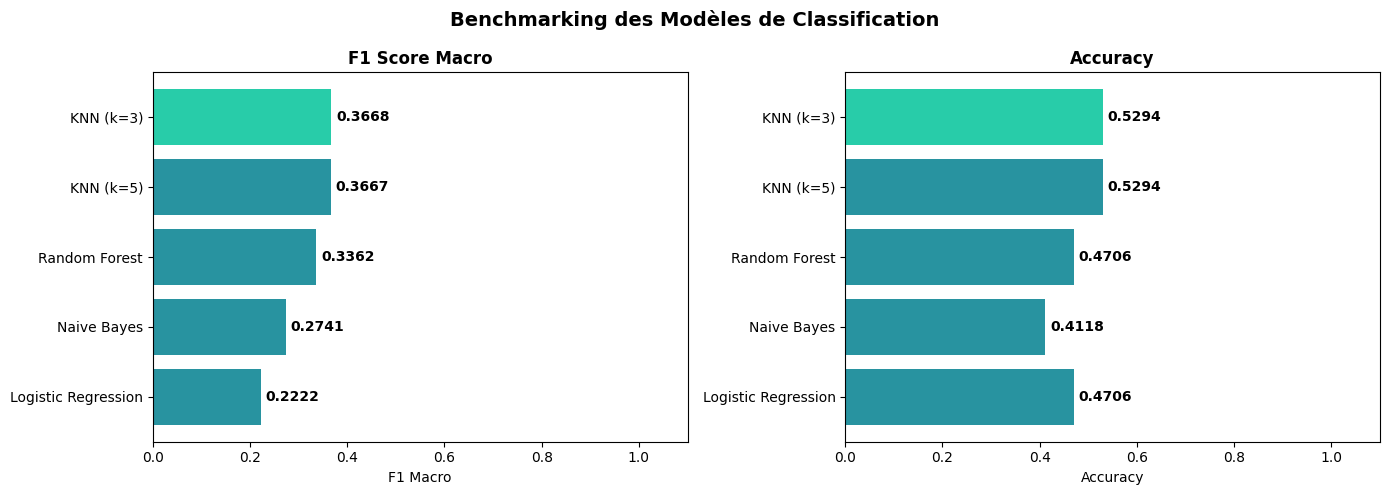

📸 Graphique sauvegardé : benchmarking_modeles.png


In [ ]:
# ─── Visualisation du benchmarking ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Benchmarking des Modèles de Classification', fontsize=14, fontweight='bold')

model_names = bench_df['Modèle']
f1_vals     = bench_df['F1 Macro']
acc_vals    = bench_df['Accuracy']

colors_bar = ['#02C39A' if i == 0 else '#028090' for i in range(len(bench_df))]

bars1 = ax1.barh(model_names[::-1], f1_vals[::-1], color=colors_bar[::-1], alpha=0.85)
ax1.set_title('F1 Score Macro', fontweight='bold')
ax1.set_xlabel('F1 Macro')
ax1.set_xlim(0, 1.1)
for bar, v in zip(bars1, f1_vals[::-1]):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

bars2 = ax2.barh(model_names[::-1], acc_vals[::-1], color=colors_bar[::-1], alpha=0.85)
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Accuracy')
ax2.set_xlim(0, 1.1)
for bar, v in zip(bars2, acc_vals[::-1]):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('benchmarking_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Graphique sauvegardé : benchmarking_modeles.png')

=== Rapport de classification — KNN (k=3) ===
                  precision    recall  f1-score   support

MANAGERIAL_SKILL       0.33      0.40      0.36         5
      SOFT_SKILL       0.00      0.00      0.00         4
 TECHNICAL_SKILL       0.64      0.88      0.74         8

        accuracy                           0.53        17
       macro avg       0.32      0.42      0.37        17
    weighted avg       0.40      0.53      0.45        17



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


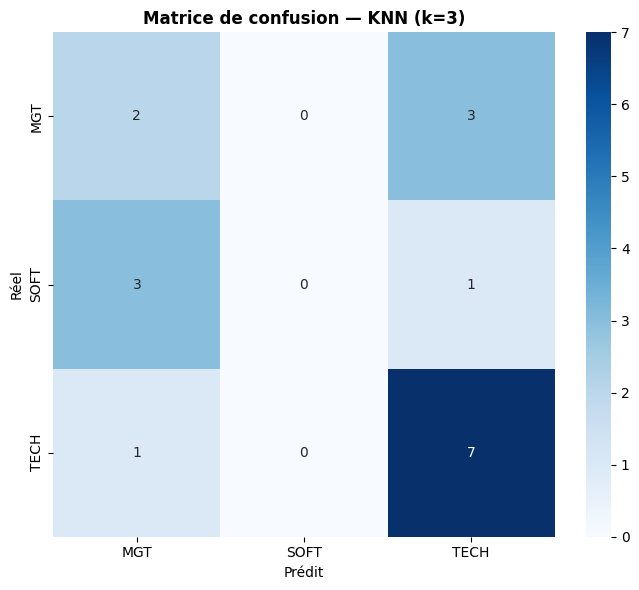

📸 Graphique sauvegardé : matrice_confusion.png


In [ ]:
# ─── Rapport détaillé du meilleur modèle ───
best_model  = results[best_name]['model']
best_y_pred = results[best_name]['y_pred']

print(f'=== Rapport de classification — {best_name} ===')
print(classification_report(y_test, best_y_pred,
                             target_names=['MANAGERIAL_SKILL', 'SOFT_SKILL', 'TECHNICAL_SKILL']))

# ─── Matrice de confusion ───
cm = confusion_matrix(y_test, best_y_pred,
                      labels=['MANAGERIAL_SKILL', 'SOFT_SKILL', 'TECHNICAL_SKILL'])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['MGT', 'SOFT', 'TECH'],
            yticklabels=['MGT', 'SOFT', 'TECH'])
ax.set_title(f'Matrice de confusion — {best_name}', fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Graphique sauvegardé : matrice_confusion.png')

In [ ]:
# ─── Cross-validation du meilleur modèle ───
print(f'⏳ Cross-validation (5-fold) — {best_name}...')
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='f1_macro', n_jobs=-1)
print(f'\nF1 Macro par fold : {cv_scores.round(4)}')
print(f'Moyenne : {cv_scores.mean():.4f} (±{cv_scores.std():.4f})')

⏳ Cross-validation (5-fold) — KNN (k=3)...

F1 Macro par fold : [0.3064 0.1846 0.364  0.3833 0.2939]
Moyenne : 0.3064 (±0.0696)


## 💾 7. Export de la Sortie Normalisée

In [ ]:
# ─── Création du dataset de sortie normalisé ───
output_df = df[[
    'job_title', 'job_category', 'seniority',
    'Technical_Skills', 'Managerial_Skills', 'Soft_Skills_NLP',
    'Technical_Count', 'Managerial_Count', 'Soft_Count', 'Total_Skills'
]].copy()

# Convertit les listes en chaînes pour l'export CSV
for col in ['Technical_Skills', 'Managerial_Skills', 'Soft_Skills_NLP']:
    output_df[col + '_str'] = output_df[col].apply(lambda x: ' | '.join(x) if x else '')

print(f'✅ Dataset de sortie : {output_df.shape}')
print(f'   Lignes avec compétences : {(output_df["Total_Skills"] > 0).sum()}')
print('\nAperçu :')
output_df[['job_title', 'Technical_Skills_str', 'Managerial_Skills_str', 'Soft_Skills_NLP_str']].head()

✅ Dataset de sortie : (20287, 13)
   Lignes avec compétences : 17752

Aperçu :


,job_title,Technical_Skills_str,Managerial_Skills_str,Soft_Skills_NLP_str
0,Admin Assistant [$1.5k-$2.2k / Bukit Batuk ...,,coordination,
1,"Visual Designer, Google Pay - Singapore",photoshop,,interpersonal skills | problem solving
2,IT Manager,,management | project management | training,communication | initiative
3,Active Directory Consultant,data analysis,coordination | management | planning | project...,collaboration
4,Senior Consultant (SAP HCM),sap,management | training,communication | initiative


In [ ]:
# ─── Sauvegarde dans Google Drive ───
OUTPUT_PATH = '/content/drive/MyDrive/competences_extraites_Objectif1.csv'

output_df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f'✅ Fichier sauvegardé : {OUTPUT_PATH}')
print(f'   {len(output_df)} entrées exportées')

# Affichage d'un exemple de sortie normalisée
print('\n=== Exemple de sortie normalisée (1 entrée) ===')
sample = output_df[output_df['Total_Skills'] > 2].iloc[0]
print(f"Poste        : {sample['job_title']}")
print(f"Techniques   : {sample['Technical_Skills']}")
print(f"Managériales : {sample['Managerial_Skills']}")
print(f"Soft Skills  : {sample['Soft_Skills_NLP']}")
print(f"Total        : {sample['Total_Skills']} compétences")

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive'

## ✅ 8. Résumé Final

| Étape | Méthode | Résultat |
|-------|---------|----------|
| Nettoyage | Regex + lowercase | Textes normalisés |
| Extraction | spaCy EntityRuler | Compétences TECH / MGT / SOFT |
| Vectorisation | TF-IDF (ngram 1-2) | Matrice (N x 1000) |
| Classification | KNN + LR + NB + RF | Benchmarking multi-modèles |
| Sortie | CSV normalisé | `competences_extraites_Objectif1.csv` |

> **→ Ce fichier CSV alimente directement l'Objectif 2 (Classification) et l'Objectif 3 (Clustering).**